1. مين اغنى حدا؟
2. كم حدا بنى ثروته لحالو؟
3. كم نسبة الاناث الغنيات؟ و كم تساوي ثروتهم؟
4. مقارنة بين الاناث و الرجال؟
5. شو متوسط اعمار الاغنياء؟
6. شو المناصب يلي بيشغلوها حاليا؟
7. من وين مصادر ثروة الاغنياء
8. شو المجالات يلي بيشتغلو فيها؟
9. شو المدينة او البلد يلي جاي منو الغني
10. من اي جنسيات الاغنياء
11. نسبة النساء يلي عملوا ثروتهم من حالهم الى النساء يلي ما عملوها من حالهم؟
12. نسبة الرجال يلي عملوا ثروتهم من حالهم الى الرجال يلي ما عملوها من حالهم؟
13. التوزع الجغرافي للاغنياء

In [2]:
import numpy  as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
sns.set_theme(rc={'figure.figsize':(8, 8)}, font_scale=1.3)
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')



In [9]:
df = pd.read_csv(r"Forbes-2022-Billionaires-db.csv",
                 encoding="latin-1") #utf-8

In [10]:
df.head()

,rank,personName,age,finalWorth,year,month,category,source,country,state,city,countryOfCitizenship,organization,selfMade,gender,birthDate,title,philanthropyScore,residenceMsa,numberOfSiblings,bio,about
0,1,Elon Musk,50.0,219000.0,2022,4,Automotive,"Tesla, SpaceX",United States,Texas,Austin,United States,Tesla,True,M,1971-06-28,CEO,1.0,NaN,NaN,Elon Musk is working to revolutionize transpor...,Musk was accepted to a graduate program at Sta...
1,2,Jeff Bezos,58.0,171000.0,2022,4,Technology,Amazon,United States,Washington,Seattle,United States,Amazon,True,M,1964-01-12,Entrepreneur,1.0,"Seattle-Tacoma-Bellevue, WA",NaN,Jeff Bezos founded e-commerce giant Amazon in ...,"Growing up, Jeff Bezos worked summers on his g..."
2,3,Bernard Arnault & family,73.0,158000.0,2022,4,Fashion & Retail,LVMH,France,NaN,Paris,France,LVMH MoÃ«t Hennessy Louis Vuitton,False,M,1949-03-05,Chairman and CEO,NaN,NaN,NaN,Bernard Arnault oversees the LVMH empire of so...,"Arnault apparently wooed his wife, Helene Merc..."
3,4,Bill Gates,66.0,129000.0,2022,4,Technology,Microsoft,United States,Washington,Medina,United States,Bill & Melinda Gates Foundation,True,M,1955-10-28,Cofounder,4.0,"Seattle-Tacoma-Bellevue, WA",NaN,Bill Gates turned his fortune from software fi...,"When Gates was a kid, he spent so much time re..."
4,5,Warren Buffett,91.0,118000.0,2022,4,Finance & Investments,Berkshire Hathaway,United States,Nebraska,Omaha,United States,Berkshire Hathaway,True,M,1930-08-30,CEO,5.0,"Omaha, NE",NaN,"Known as the ""Oracle of Omaha,"" Warren Buffett...","Buffett still lives in the same Omaha, Nebrask..."


In [11]:
df.tail()

,rank,personName,age,finalWorth,year,month,category,source,country,state,city,countryOfCitizenship,organization,selfMade,gender,birthDate,title,philanthropyScore,residenceMsa,numberOfSiblings,bio,about
2663,2578,Zhang Yuqiang,66.0,1000.0,2022,4,Manufacturing,Fiberglass,China,NaN,Tongxiang,China,NaN,True,M,1955-09-01,NaN,NaN,NaN,NaN,"Zhang Yuqiang chairs Zhenshi Holding Group, a ...",NaN
2664,2578,Zhou Ruxin,59.0,1000.0,2022,4,Technology,Navigation,China,NaN,Beijing,China,NaN,True,M,1963-03-01,NaN,NaN,NaN,NaN,"Zhou Ruxin chairs Beijing BDStar Navigation, a...",NaN
2665,2578,Wen Zhou & family,57.0,1000.0,2022,4,Manufacturing,chemicals,China,NaN,Shanghai,China,NaN,True,M,1965-03-06,NaN,NaN,NaN,NaN,"Zhou Wen chairs Shanghai Pret Composites, a su...",NaN
2666,2578,Zhou Yifeng & family,43.0,1000.0,2022,4,Energy,liquefied petroleum gas,China,NaN,Zhangjiagang,China,NaN,True,F,1978-07-11,NaN,NaN,NaN,NaN,Zhou Yifeng chairs Shenzhen-listed Oriental En...,NaN
2667,2578,Zhuang Kuilong & family,59.0,1000.0,2022,4,Manufacturing,polyester,China,NaN,Jiaxing,China,NaN,True,M,1962-06-15,NaN,NaN,NaN,NaN,"Zhuang Kuilong chairs Xinfengming Group, a man...",NaN


In [12]:
df.sample(10)

,rank,personName,age,finalWorth,year,month,category,source,country,state,city,countryOfCitizenship,organization,selfMade,gender,birthDate,title,philanthropyScore,residenceMsa,numberOfSiblings,bio,about
1310,1292,Joe Lau,32.0,2400.0,2022,4,Technology,"blockchain, technology",United States,California,Stanford,United States,NaN,True,M,1989-07-01,NaN,NaN,NaN,NaN,"Joe Lau cofounded Alchemy, whose software powe...",Alchemy's team consists of engineers from Goog...
849,822,Wenzhong Zhang,60.0,3600.0,2022,4,Fashion & Retail,supermarkets,China,NaN,Beijing,China,NaN,True,M,1962-01-01,NaN,NaN,NaN,NaN,Zhang Wenzhong is the controlling shareholding...,NaN
2435,2324,J. Wayne Weaver,86.0,1200.0,2022,4,Diversified,Shoes,United States,Florida,Jacksonville,United States,NaN,True,M,1935-09-01,NaN,NaN,"Jacksonville, FL",NaN,Wayne Weaver is the chairman of shoe retailer ...,Weaver grew up in public housing and did odd j...
680,665,Richard Schulze,81.0,4300.0,2022,4,Fashion & Retail,Best Buy,United States,Florida,Bonita Springs,United States,Best Buy,True,M,1941-01-02,Chairman,2.0,"Cape Coral, FL",NaN,Richard Schulze worked as an electronics compo...,"In 2019, Best Buy named Corie Barry as CEO. Sh..."
462,460,Frits Goldschmeding,88.0,5700.0,2022,4,Service,temp agency,Netherlands,NaN,Amsterdam,Netherlands,NaN,True,M,1933-08-02,NaN,NaN,NaN,NaN,The bulk of Frits Goldschmeding's fortune come...,"In 2015, he started The Goldschmeding Foundati..."
1645,1645,Igor Altushkin,51.0,1800.0,2022,4,Metals & Mining,metals,Russia,NaN,Yekaterinburg,Russia,NaN,True,M,1970-09-10,NaN,NaN,NaN,NaN,Igor Altushkin is the founder and largest shar...,Altushkin owns one of Madonna's former homes i...
301,296,Blair Parry-Okeden,71.0,7800.0,2022,4,Media & Entertainment,"media, automotive",Australia,NaN,New South Wales,United States,NaN,False,F,1950-05-21,NaN,1.0,NaN,NaN,Blair Parry-Okeden inherited a 25% stake in Co...,Blair Parry-Okeden grew up in Hawaii and now l...
1346,1341,Richard Chandler,63.0,2300.0,2022,4,Finance & Investments,investments,Singapore,NaN,Singapore,New Zealand,NaN,False,M,1959-01-01,NaN,NaN,NaN,NaN,"A native of New Zealand, Richard Chandler relo...",NaN
602,601,Richard Branson,71.0,4700.0,2022,4,Diversified,Virgin,British Virgin Islands,NaN,Necker Island,United Kingdom,NaN,True,M,1950-07-18,NaN,NaN,NaN,NaN,Richard Branson owes his fortune to a conglome...,When he sold Virgin Records for $1 billion in ...
2173,2076,Wang Jian,68.0,1400.0,2022,4,Technology,healthcare services,China,NaN,Shenzhen,China,NaN,True,M,1954-01-01,NaN,NaN,NaN,NaN,"Wang Jian is the president of BGI, one of Asia...",NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2668 entries, 0 to 2667
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rank                  2668 non-null   int64  
 1   personName            2668 non-null   object 
 2   age                   2582 non-null   float64
 3   finalWorth            2668 non-null   float64
 4   year                  2668 non-null   int64  
 5   month                 2668 non-null   int64  
 6   category              2668 non-null   object 
 7   source                2668 non-null   object 
 8   country               2655 non-null   object 
 9   state                 748 non-null    object 
 10  city                  2624 non-null   object 
 11  countryOfCitizenship  2668 non-null   object 
 12  organization          352 non-null    object 
 13  selfMade              2668 non-null   bool   
 14  gender                2652 non-null   object 
 15  birthDate            

In [14]:
df.shape

(2668, 22)

In [15]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rank,2668.0,NaN,NaN,NaN,1302.91904,747.807782,1.0,665.0,1292.0,1929.0,2578.0
personName,2668,2666,Li Li,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2582.0,NaN,NaN,NaN,64.210689,13.401258,19.0,55.0,64.0,74.0,100.0
finalWorth,2668.0,NaN,NaN,NaN,4762.350075,10540.482258,1000.0,1500.0,2400.0,4300.0,219000.0
year,2668.0,NaN,NaN,NaN,2022.0,0.0,2022.0,2022.0,2022.0,2022.0,2022.0
month,2668.0,NaN,NaN,NaN,4.0,0.0,4.0,4.0,4.0,4.0,4.0
category,2668,18,Finance & Investments,392,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,2668,914,real estate,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,2655,73,United States,748,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,748,42,California,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.describe(include='object')

,personName,category,source,country,state,city,countryOfCitizenship,organization,gender,birthDate,title,residenceMsa,bio,about
count,2668,2668,2668,2655,748,2624,2668,352,2652,2569,401,639,2668,1562
unique,2666,18,914,73,42,749,75,316,2,2044,94,109,2668,1548
top,Li Li,Finance & Investments,real estate,United States,California,New York,United States,Meta Platforms,M,1965-01-01,Entrepreneur,"New York, NY",Elon Musk is working to revolutionize transpor...,"The family's Knauf Museum, on the premises of ..."
freq,2,392,151,748,186,106,735,4,2341,19,73,119,1,4


# **Analysis and Visualization**

In [14]:
# Checking Null values
df.isnull().sum().sort_values(ascending=False)

numberOfSiblings        2541
organization            2316
philanthropyScore       2272
title                   2267
residenceMsa            2029
state                   1920
about                   1106
birthDate                 99
age                       86
city                      44
gender                    16
country                   13
bio                        0
rank                       0
selfMade                   0
personName                 0
source                     0
category                   0
month                      0
year                       0
finalWorth                 0
countryOfCitizenship       0
dtype: int64

In [15]:
df.columns

Index(['rank', 'personName', 'age', 'finalWorth', 'year', 'month', 'category',
       'source', 'country', 'state', 'city', 'countryOfCitizenship',
       'organization', 'selfMade', 'gender', 'birthDate', 'title',
       'philanthropyScore', 'residenceMsa', 'numberOfSiblings', 'bio',
       'about'],
      dtype='object')

In [7]:
#Return percentage of missing values in each column  
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{}  -  {}%'.format(col, round(pct_missing*100)))

rank  -  0%
personName  -  0%
age  -  3%
finalWorth  -  0%
year  -  0%
month  -  0%
category  -  0%
source  -  0%
country  -  0%
state  -  72%
city  -  2%
countryOfCitizenship  -  0%
organization  -  87%
selfMade  -  0%
gender  -  1%
birthDate  -  4%
title  -  85%
philanthropyScore  -  85%
residenceMsa  -  76%
numberOfSiblings  -  95%
bio  -  0%
about  -  41%


In [8]:
#Drop columns that contain 30% or more  missing values 
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    pct_missing =  round(pct_missing*100)
    if pct_missing >= 30 :
      df.drop([col],axis = 1,inplace = True)
      print('Droping {} Column as it contain - {}% null values'.format(col, pct_missing))


Droping state Column as it contain - 72% null values
Droping organization Column as it contain - 87% null values
Droping title Column as it contain - 85% null values
Droping philanthropyScore Column as it contain - 85% null values
Droping residenceMsa Column as it contain - 76% null values
Droping numberOfSiblings Column as it contain - 95% null values
Droping about Column as it contain - 41% null values


In [9]:
df.shape

(2668, 15)

In [10]:
for column in df.columns:
    if df[column].dtype == 'object':  # For categorical columns
        df[column] = df[column].fillna(df[column].mode()[0])
    elif df[column].dtype in ['int64', 'float64']:  # For numerical columns
        df[column] = df[column].fillna(df[column].mean())

In [11]:
df.isnull().sum()

rank                    0
personName              0
age                     0
finalWorth              0
year                    0
month                   0
category                0
source                  0
country                 0
city                    0
countryOfCitizenship    0
selfMade                0
gender                  0
birthDate               0
bio                     0
dtype: int64

In [12]:
df.head()

,rank,personName,age,finalWorth,year,month,category,source,country,city,countryOfCitizenship,selfMade,gender,birthDate,bio
0,1,Elon Musk,50.0,219000.0,2022,4,Automotive,"Tesla, SpaceX",United States,Austin,United States,True,M,1971-06-28,Elon Musk is working to revolutionize transpor...
1,2,Jeff Bezos,58.0,171000.0,2022,4,Technology,Amazon,United States,Seattle,United States,True,M,1964-01-12,Jeff Bezos founded e-commerce giant Amazon in ...
2,3,Bernard Arnault & family,73.0,158000.0,2022,4,Fashion & Retail,LVMH,France,Paris,France,False,M,1949-03-05,Bernard Arnault oversees the LVMH empire of so...
3,4,Bill Gates,66.0,129000.0,2022,4,Technology,Microsoft,United States,Medina,United States,True,M,1955-10-28,Bill Gates turned his fortune from software fi...
4,5,Warren Buffett,91.0,118000.0,2022,4,Finance & Investments,Berkshire Hathaway,United States,Omaha,United States,True,M,1930-08-30,"Known as the ""Oracle of Omaha,"" Warren Buffett..."


In [17]:
df['finalWorth'] = df['finalWorth'] / 1000

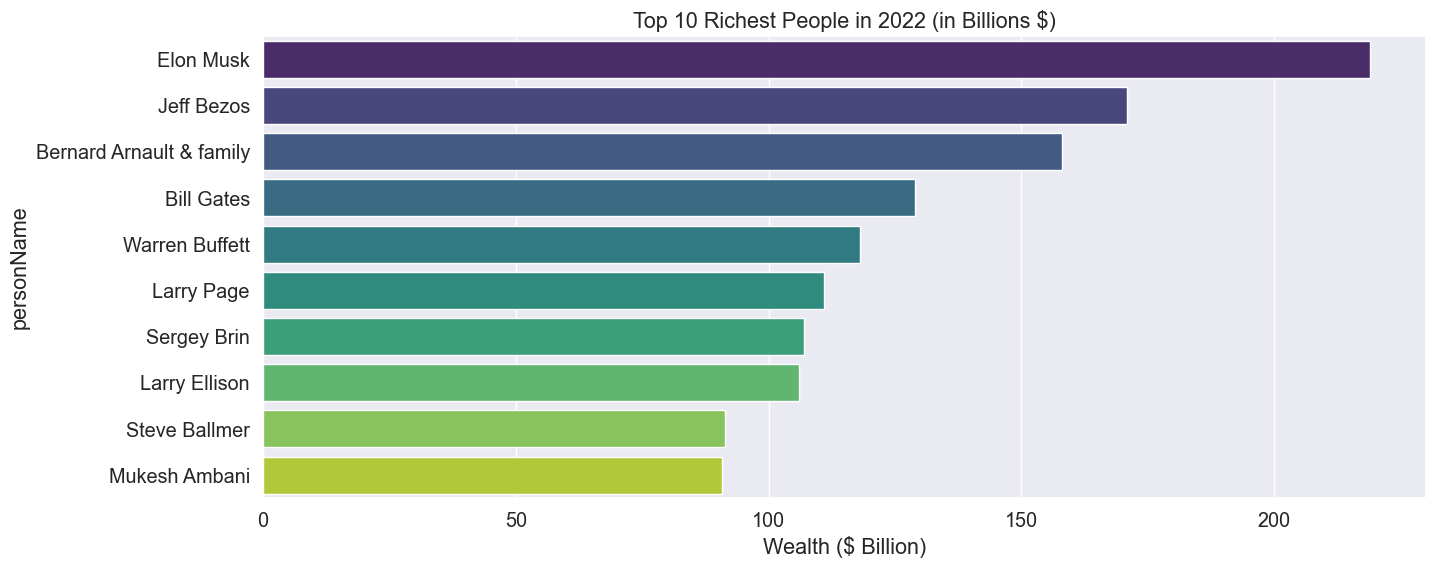

In [22]:
top_10 = df.head(10)
plt.figure(figsize=(15, 6))
sns.barplot(data=top_10, x='finalWorth', y='personName', palette='viridis')
plt.title('Top 10 Richest People in 2022 (in Billions $)')
plt.xlabel('Wealth ($ Billion)')
plt.show()

## Gender Analysis

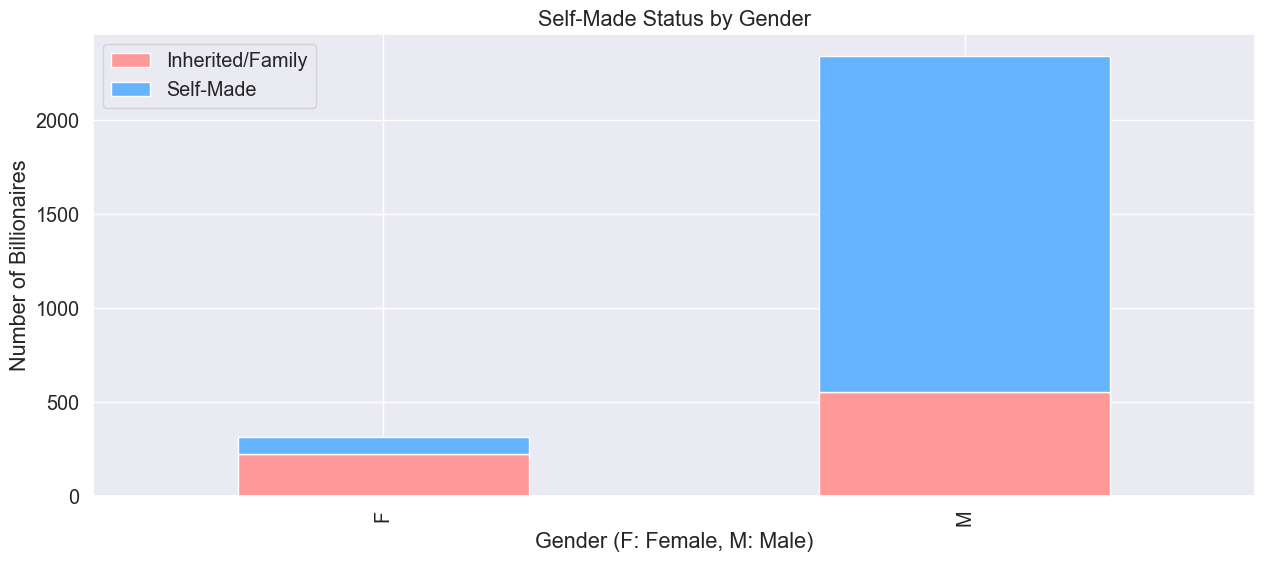

In [24]:
# حساب النسب
gender_self_made = df.groupby(['gender', 'selfMade']).size().unstack()

# رسم بياني
gender_self_made.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], figsize=(15,6))
plt.title('Self-Made Status by Gender')
plt.ylabel('Number of Billionaires')
plt.xlabel('Gender (F: Female, M: Male)')
plt.legend(['Inherited/Family', 'Self-Made'])
plt.show()

## توزيع الأعمار
بدنا نشوف هل المليارديرات "ختيارية" ولا في جيل شباب عم يكتسح؟

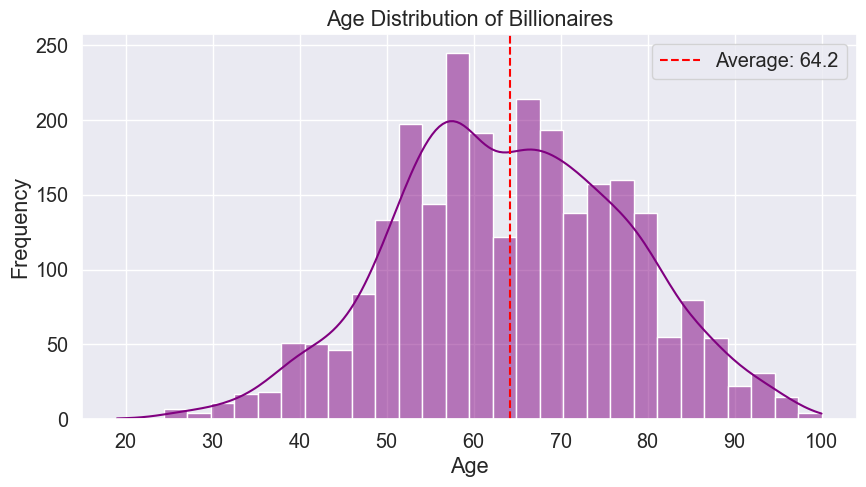

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age'].dropna(), bins=30, kde=True, color='purple')
plt.title('Age Distribution of Billionaires')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Average: {df["age"].mean():.1f}')
plt.legend()
plt.show()

## 1. مين أغنى حدا؟

In [27]:
df.iloc[0]['personName']

'Elon Musk'

## 2. كم حدا عصامي؟

In [28]:
df['selfMade'].value_counts()

selfMade
True     1891
False     777
Name: count, dtype: int64

## . المصادر والمجالات

In [29]:
df['category'].value_counts().head(5)

category
Finance & Investments    392
Technology               343
Manufacturing            337
Fashion & Retail         250
Healthcare               217
Name: count, dtype: int64

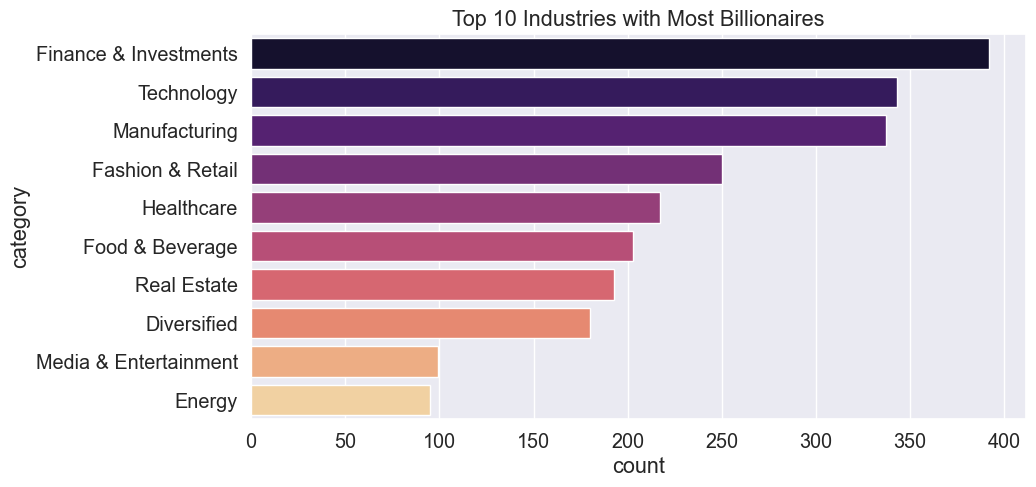

In [30]:
# رسم بياني لأكبر 5 مجالات مولدة للثروة
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index[:10], palette='magma')
plt.title('Top 10 Industries with Most Billionaires')
plt.show()

## تحليل النوع الاجتماعي

In [31]:
# 3 & 4. نسبة الإناث وإجمالي ثروتهن
female_df = df[df['gender'] == 'F']
male_df = df[df['gender'] == 'M']

print(f"نسبة الإناث: {len(female_df) / len(df) * 100:.2f}%")
print(f"إجمالي ثروة الإناث: {female_df['finalWorth'].sum():.2f} Billion $")

# 11 & 12. العصامية بين الجنسين (Self-made ratio)
self_made_gender = df.groupby('gender')['selfMade'].value_counts(normalize=True).unstack() * 100
print(self_made_gender)

نسبة الإناث: 11.66%
إجمالي ثروة الإناث: 1445.30 Billion $
selfMade      False      True 
gender                        
F         71.061093  28.938907
M         23.536950  76.463050


### Insight: رح تلاحظ إن نسبة "العصامية" عند الرجال غالباً أعلى بكتير من النساء في داتاسيت 2022، حيث أن أغلب النساء المليارديرات ورثن الثروة أو شاركن في بناء شركات عائلية.

## الجغرافيا والأعمار

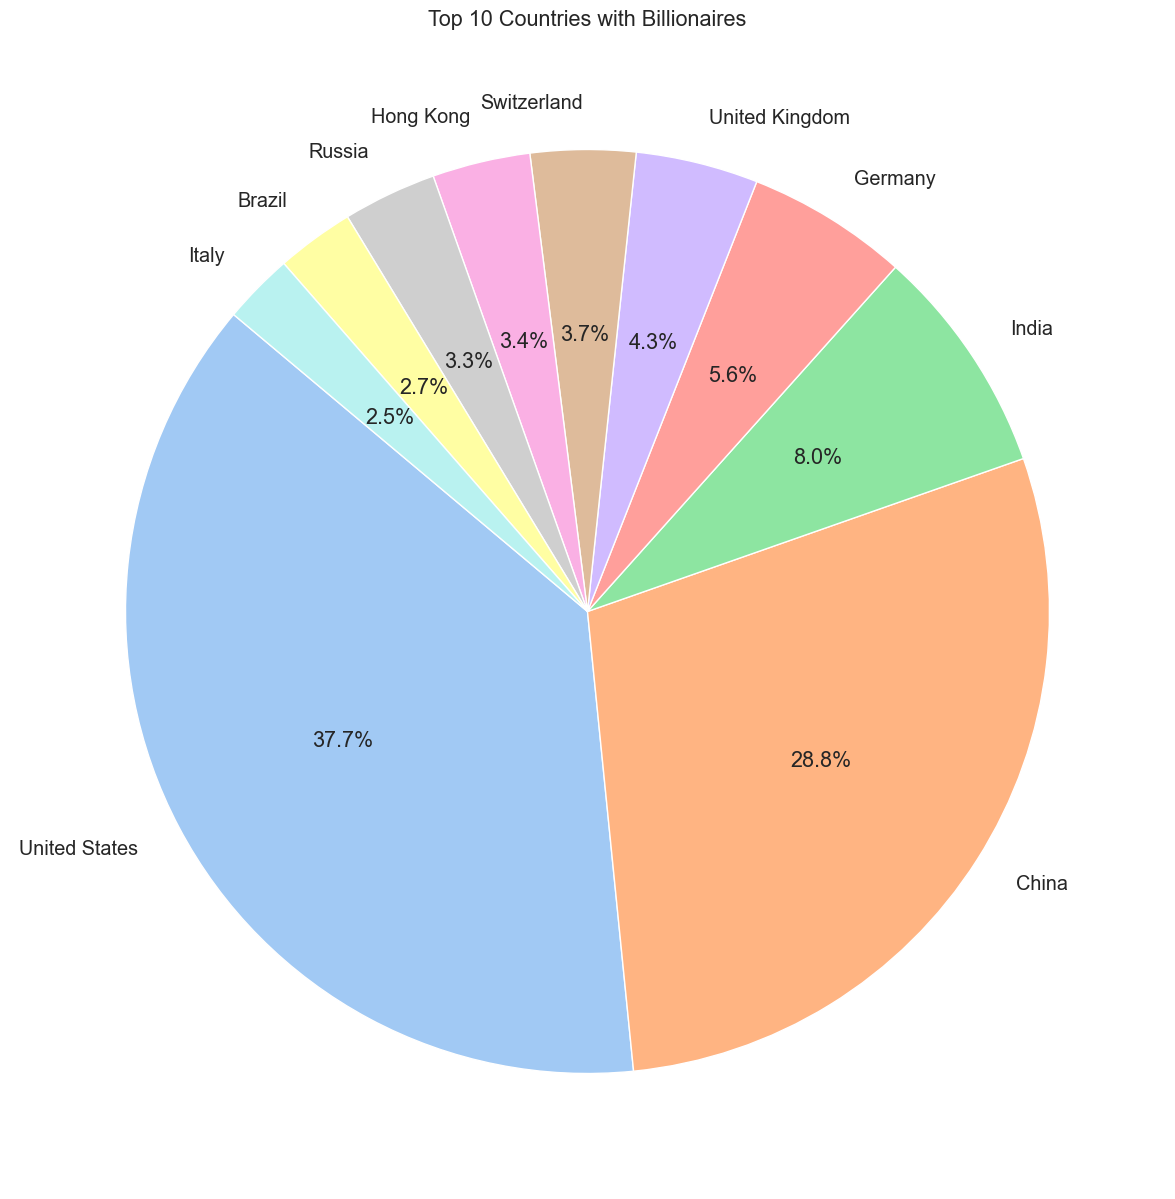

In [41]:
# 5. متوسط الأعمار
avg_age = df['age'].mean()

# 9 & 10. الجنسيات والدول
top_countries = df['country'].value_counts().head(10)

# 13. التوزع الجغرافي (أهم 5 دول)
plt.figure(figsize=(20,15))
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Top 10 Countries with Billionaires')
plt.show()

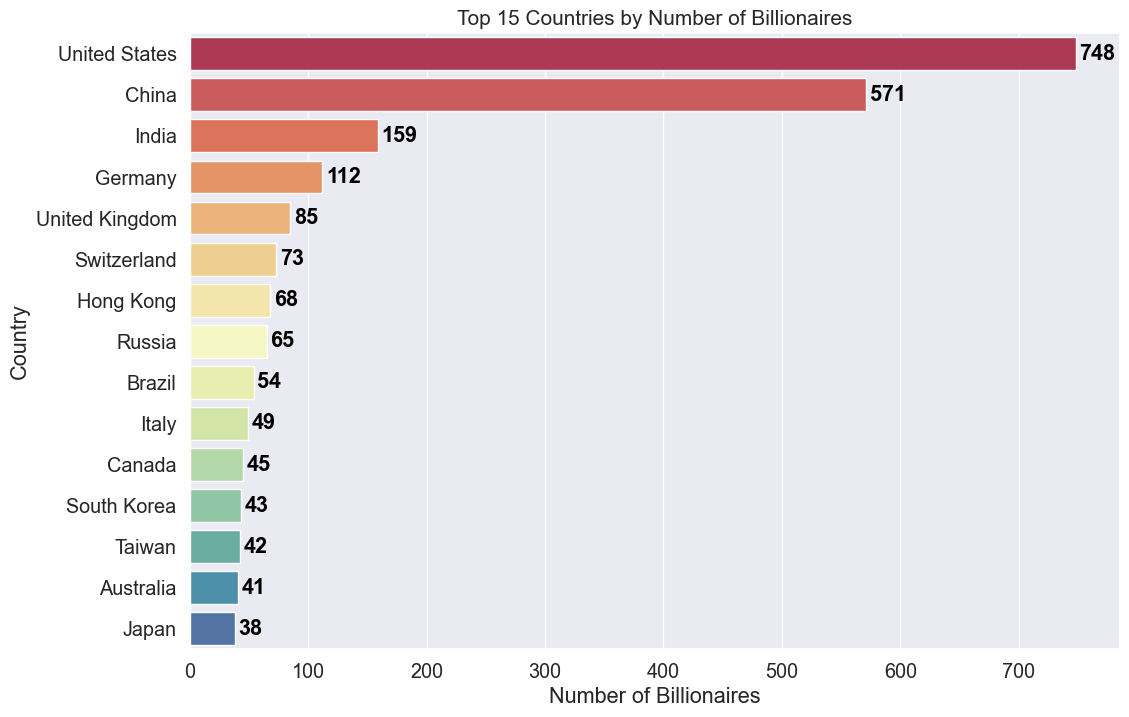

In [45]:
# تجهيز البيانات (أعلى 15 دولة عشان نختبر قوة الرسمة)
top_countries = df['country'].value_counts().head(15)

# --- الخيار الأول: Horizontal Bar Chart (كلاسيكي ونظيف) ---
plt.figure(figsize=(12, 8))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Spectral')
plt.title('Top 15 Countries by Number of Billionaires', fontsize=15)
plt.xlabel('Number of Billionaires')
plt.ylabel('Country')

# إضافة الأرقام على طرف كل عمود لزيادة الوضوح
for i, v in enumerate(top_countries.values):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.show()